# Подготовка данных для загрузки в модель.

In [1]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from multiprocessing import freeze_support
import matplotlib.pyplot as plt


class SegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Преобразование маски для бинарной сегментации
        mask = mask.float()
        mask = mask.unsqueeze(0)

        return image, mask


# Аугментация
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

c:\ProgramData\anaconda3\envs\vkr\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
n_cpu = os.cpu_count()
train_dataset = SegmentationDataset(
    image_dir=r'D:\URFU\VKR\Ind_pract\dissert\data\test\data\train\images',
    mask_dir=r'D:\URFU\VKR\Ind_pract\dissert\data\test\data\train\masks',
    transform=train_transform
)

valid_dataset = SegmentationDataset(
    image_dir=r'D:\URFU\VKR\Ind_pract\dissert\data\test\data\val\images',
    mask_dir=r'D:\URFU\VKR\Ind_pract\dissert\data\test\data\val\masks',
    transform=train_transform
)

test_dataset = SegmentationDataset(
    image_dir=r'D:\URFU\VKR\Ind_pract\dissert\data\test\data\test\images',
    mask_dir=r'D:\URFU\VKR\Ind_pract\dissert\data\test\data\test\masks',
    transform=train_transform
)

train_loader = DataLoader(train_dataset,
                                batch_size=4,
                                shuffle=True
                                )
valid_loader = DataLoader(valid_dataset,
                                batch_size=4
                                )
test_loader = DataLoader(test_dataset,
                                batch_size=4 
                                )

images, masks = next(iter(train_loader))
print("Размерность изображений:", images.shape)
print("Размерность масок:", masks.shape)
print("Тип изображений:", images.dtype)
print("Тип масок:", masks.dtype)
print("Классы:", masks.unique())


Размерность изображений: torch.Size([4, 3, 256, 256])
Размерность масок: torch.Size([4, 1, 256, 256])
Тип изображений: torch.float32
Тип масок: torch.float32
Классы: tensor([0., 1.])


# Пример данных 

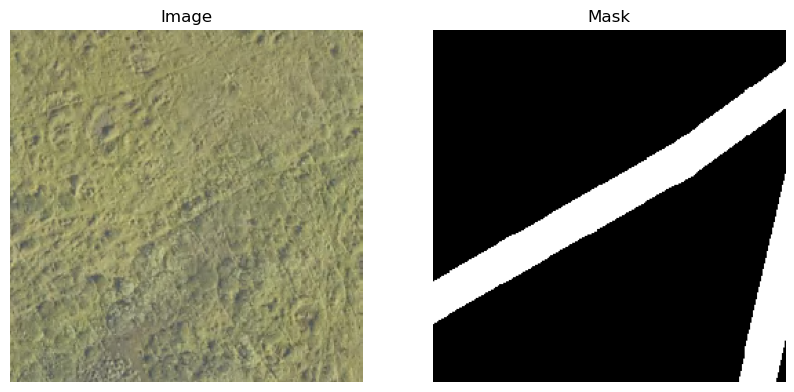

In [3]:
import numpy as np

# Функция для денормализации изображения
def denormalize(image, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    image = image.clone()  # Создаём копию тензора
    for i in range(3):  # Денормализация для каждого канала
        image[i] = image[i] * std[i] + mean[i]
    return image

# Получение одного примера из датасета
sample = train_dataset[10]
image, mask = sample  # Распаковка кортежа

# Подготовка изображения для визуализации
image = denormalize(image)  # Денормализация
image = image.permute(1, 2, 0)  # Транспонирование: [C, H, W] -> [H, W, C]
image = image.numpy()  # Конвертация в numpy для plt.imshow
image = np.clip(image, 0, 1)  # Ограничение значений для корректного отображения

# Подготовка маски для визуализации
mask = mask.squeeze()  # Удаление канала: [1, H, W] -> [H, W]
mask = mask.numpy()  # Конвертация в numpy

# Визуализация
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask, cmap='gray')  # Используем cmap='gray' для маски
plt.axis('off')

plt.show()

# Model U-net

In [4]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import Callback
from pytorch_lightning.loggers import TensorBoardLogger

class DoubleConv(nn.Module):
    """Блок двойной свёртки: Conv -> BN -> ReLU -> Conv -> BN -> ReLU"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class PlotMetricsCallback(Callback):
    """Кастомный callback для динамической визуализации метрик с Matplotlib"""
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []
        self.val_dices = []
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2, figsize=(12, 5))
        plt.ion()  # Включить интерактивный режим

    def on_train_epoch_end(self, trainer, pl_module):
        # Собираем метрики за эпоху
        train_loss = trainer.callback_metrics.get('train_loss', None)
        val_loss = trainer.callback_metrics.get('val_loss', None)
        val_dice = trainer.callback_metrics.get('val_dice', None)

        if train_loss is not None:
            self.train_losses.append(train_loss.item())
        if val_loss is not None:
            self.val_losses.append(val_loss.item())
        if val_dice is not None:
            self.val_dices.append(val_dice.item())

        # Обновляем графики
        self.ax1.clear()
        self.ax2.clear()

        # График потерь
        self.ax1.plot(self.train_losses, label='Train Loss', color='blue')
        self.ax1.plot(self.val_losses, label='Val Loss', color='orange')
        self.ax1.set_title('Loss over Epochs')
        self.ax1.set_xlabel('Epoch')
        self.ax1.set_ylabel('Loss')
        self.ax1.legend()
        self.ax1.grid(True)

        # График Dice
        self.ax2.plot(self.val_dices, label='Val Dice', color='green')
        self.ax2.set_title('Dice Score over Epochs')
        self.ax2.set_xlabel('Epoch')
        self.ax2.set_ylabel('Dice Score')
        self.ax2.legend()
        self.ax2.grid(True)

        self.fig.tight_layout()
        plt.draw()
        plt.pause(0.1)  # Небольшая пауза для обновления графика

    def on_train_end(self, trainer, pl_module):
        plt.ioff()  # Выключить интерактивный режим
        plt.show()  # Показать финальный график

class UNet(pl.LightningModule):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512], learning_rate=1e-3, pretrained_weights_path=None):
        super().__init__()
        self.save_hyperparameters()
        self.learning_rate = learning_rate

        # Энкодер (сжатие)
        self.encoder1 = DoubleConv(in_channels, features[0])
        self.encoder2 = DoubleConv(features[0], features[1])
        self.encoder3 = DoubleConv(features[1], features[2])
        self.encoder4 = DoubleConv(features[2], features[3])
        
        # Бутылочное горлышко
        self.bottleneck = DoubleConv(features[3], features[3]*2)
        
        # Декодер (расширение)
        self.upconv4 = nn.ConvTranspose2d(features[3]*2, features[3], kernel_size=2, stride=2)
        self.decoder4 = DoubleConv(features[3]*2, features[3])
        self.upconv3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.decoder3 = DoubleConv(features[2]*2, features[2])
        self.upconv2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(features[1]*2, features[1])
        self.upconv1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(features[0]*2, features[0])
        
        # Выходной слой (1 класс, бинарная сегментация)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        
        # Pooling для энкодера
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Загрузка предобученных весов, если указан путь
        if pretrained_weights_path is not None:
            try:
                checkpoint = torch.load(pretrained_weights_path, map_location=self.device)
                if 'state_dict' in checkpoint:  # Формат Lightning checkpoint
                    self.load_state_dict(checkpoint['state_dict'], strict=False)
                else:  # Формат обычного .pth файла
                    self.load_state_dict(checkpoint, strict=False)
                print(f"Loaded pretrained weights from {pretrained_weights_path}")
            except Exception as e:
                print(f"Error loading pretrained weights: {e}")

    def forward(self, x):
        # Энкодер
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))
        
        # Бутылочное горлышко
        bottleneck = self.bottleneck(self.pool(enc4))
        
        # Декодер с skip-соединениями
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)  # Skip-соединение
        dec4 = self.decoder4(dec4)
        
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        
        # Выход с сигмоидой
        return torch.sigmoid(self.final_conv(dec1))

    def dice_loss(self, pred, target, smooth=1e-6):
        """Dice Loss для бинарной сегментации"""
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
        return 1 - dice

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.dice_loss(y_pred, y)
        self.log('train_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.dice_loss(y_pred, y)
        dice_score = 1 - loss  # Dice коэффициент как метрика
        self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val_dice', dice_score, prog_bar=True, on_step=False, on_epoch=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        loss = self.dice_loss(y_pred, y)
        dice_score = 1 - loss
        self.log('test_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('test_dice', dice_score, prog_bar=True, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer



# Обучение модели U-net

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params | Mode 
--------------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K | train
1  | encoder2   | DoubleConv      | 221 K  | train
2  | encoder3   | DoubleConv      | 886 K  | train
3  | encoder4   | DoubleConv      | 3.5 M  | train
4  | bottleneck | DoubleConv      | 14.2 M | train
5  | upconv4    | ConvTranspose2d | 2.1 M  | train
6  | decoder4   | DoubleConv      | 7.1 M  | train
7  | upconv3    | ConvTranspose2d | 524 K  | train
8  | decoder3   | DoubleConv      | 1.8 M  | train
9  | upconv2    | ConvTranspose2d | 131 K  | train
10 | decoder2   | DoubleConv      | 443 K  | train
11 | upconv1    | ConvTranspose2d | 32.

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\ProgramData\anaconda3\envs\vkr\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\ProgramData\anaconda3\envs\vkr\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\ProgramData\anaconda3\envs\vkr\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (48) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 48/48 [00:12<00:00,  3.84it/s, v_num=2, val_loss=0.783, val_dice=0.217]

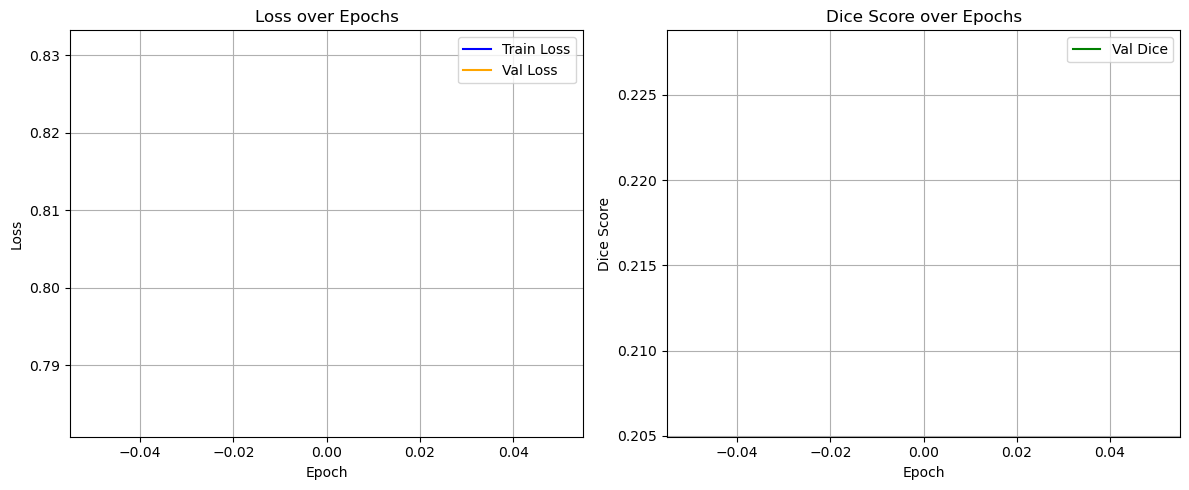

Epoch 1: 100%|██████████| 48/48 [00:12<00:00,  3.82it/s, v_num=2, val_loss=0.785, val_dice=0.215, train_loss=0.831]

<Figure size 640x480 with 0 Axes>

Epoch 2: 100%|██████████| 48/48 [00:12<00:00,  3.80it/s, v_num=2, val_loss=0.792, val_dice=0.208, train_loss=0.822]

<Figure size 640x480 with 0 Axes>

Epoch 3: 100%|██████████| 48/48 [00:12<00:00,  3.81it/s, v_num=2, val_loss=0.788, val_dice=0.212, train_loss=0.815]

...

Epoch 19: 100%|██████████| 48/48 [00:12<00:00,  3.77it/s, v_num=2, val_loss=0.781, val_dice=0.219, train_loss=0.794]

<Figure size 640x480 with 0 Axes>

Epoch 19: 100%|██████████| 48/48 [00:12<00:00,  3.70it/s, v_num=2, val_loss=0.781, val_dice=0.219, train_loss=0.801]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 48/48 [00:14<00:00,  3.30it/s, v_num=2, val_loss=0.781, val_dice=0.219, train_loss=0.801]


In [5]:

# Инициализация модели
model = UNet(
    in_channels=3,
    out_channels=1,
    learning_rate=1e-3,
    pretrained_weights_path=None  # Укажите путь к весам, если нужно
)

# Настройка логгера TensorBoard
logger = TensorBoardLogger(save_dir="logs/", name="unet_segmentation")

# Настройка тренера 
trainer = pl.Trainer(
    max_epochs=20,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    logger=logger,
    callbacks=[PlotMetricsCallback()]
)

# Обучение
trainer.fit(model, train_loader, valid_loader)



# Тестирование модели U-net

In [6]:
# Тестирование
trainer.test(model, test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\ProgramData\anaconda3\envs\vkr\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 11/11 [00:01<00:00, 10.98it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_dice            0.232346773147583
        test_loss            0.767653226852417
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.767653226852417, 'test_dice': 0.232346773147583}]